# Lab 3: Time of Flight Sensors
Data collection and plotting notebook for dual VL53L1X ToF sensors + IMU.

In [15]:
!pip install bleak colorama numpy matplotlib bleach PyYAML  --upgrade


In [16]:
%load_ext autoreload
%autoreload 2

from ble import get_ble_controller
from base_ble import LOG
from cmd_types import CMD
import time
import numpy as np
import asyncio
import matplotlib.pyplot as plt

LOG.propagate = False


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [17]:
ble = get_ble_controller()
ble.connect()


2026-03-03 06:52:51,940 | INFO     |: Already connected to a BLE device


## Notification Handler Setup
Handles IMU (`I:`), ToF sensor 1 (`D1:`), ToF sensor 2 (`D2:`), stats (`S1:`, `S2:`), and `END` markers.

In [18]:
imu_data = {
    'time': [], 'acc_x': [], 'acc_y': [], 'acc_z': [],
    'gyr_x': [], 'gyr_y': [], 'gyr_z': [],
    'mag_x': [], 'mag_y': [], 'mag_z': [],
}
tof1_data = {'time': [], 'dist': []}
tof2_data = {'time': [], 'dist': []}
tof_stats = {}
transfer_done = False

def handle_sensor_data(uuid, message):
    global imu_data, tof1_data, tof2_data, tof_stats, transfer_done
    msg = message.decode()

    if msg == "END":
        transfer_done = True
        return

    prefix = msg.split(":")[0] + ":"
    payload = msg[len(prefix):]
    parts = payload.split("|")

    if prefix == "I:":
        vals = [float(p) for p in parts]
        imu_data['time'].append(vals[0])
        for i, key in enumerate(['acc_x','acc_y','acc_z','gyr_x','gyr_y','gyr_z','mag_x','mag_y','mag_z']):
            imu_data[key].append(vals[i+1])

    elif prefix == "D1:":
        tof1_data['time'].append(float(parts[0]))
        tof1_data['dist'].append(float(parts[1]))

    elif prefix == "D2:":
        tof2_data['time'].append(float(parts[0]))
        tof2_data['dist'].append(float(parts[1]))

    elif prefix == "S1:":
        tof_stats['s1'] = {'n': int(parts[0]), 'mean': float(parts[1]), 'std': float(parts[2])}

    elif prefix == "S2:":
        tof_stats['s2'] = {'n': int(parts[0]), 'mean': float(parts[1]), 'std': float(parts[2])}

try:
    ble.stop_notify(ble.uuid["RX_STRING"])
except Exception:
    pass

ble.start_notify(ble.uuid["RX_STRING"], handle_sensor_data)
print("Notification handler ready")


Notification handler ready


---
## 1. ToF Mode Selection
Choose short (1.3m) or long (4m) distance mode for both sensors.

In [19]:
# Switch ToF mode -- run ONE of these
# ble.send_command(CMD.TOF_SHORT, "")
ble.send_command(CMD.TOF_LONG, "")


---
## 2. ToF Accuracy / Repeatability Testing
Place the robot at a known distance, wait for samples to accumulate, then request mean/std from both sensors.
Repeat at multiple distances to build an accuracy table.

In [20]:
# Set this to your measured ground-truth distance (mm)
true_distance_mm = 300

# Let buffer fill with fresh samples
time.sleep(3)

tof_stats = {}
transfer_done = False

ble.send_command(CMD.TOF_STATS, "")
while not transfer_done:
    await asyncio.sleep(0.1)

for sensor, label in [('s1', 'Sensor 1'), ('s2', 'Sensor 2')]:
    s = tof_stats.get(sensor, {'n': 0, 'mean': 0, 'std': 0})
    print(f"{label}: n={s['n']}, mean={s['mean']:.1f} mm, std={s['std']:.2f} mm, error={s['mean'] - true_distance_mm:.1f} mm")

# Append to results table
if 'tof_results' not in dir():
    tof_results = []
for sensor in ['s1', 's2']:
    s = tof_stats.get(sensor, {'n': 0, 'mean': 0, 'std': 0})
    tof_results.append({
        'sensor': sensor,
        'true_mm': true_distance_mm,
        'mean_mm': s['mean'],
        'std_mm': s['std'],
        'n': s['n'],
    })


Sensor 1: n=255, mean=13.8 mm, std=21.24 mm, error=-286.2 mm
Sensor 2: n=255, mean=143.6 mm, std=335.82 mm, error=-156.4 mm


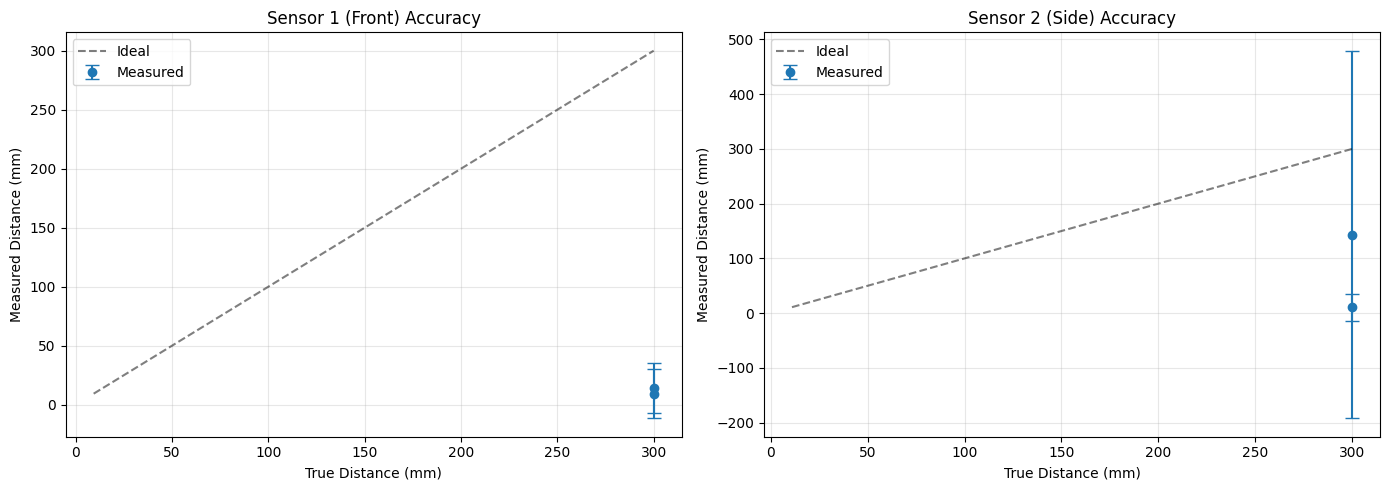

  Sensor  True (mm)  Mean (mm)   Std (mm) Error (mm)     N
----------------------------------------------------------
      s1        300        9.4      20.89     -290.6    49
      s2        300       10.9      24.48     -289.1    51
      s1        300       13.8      21.24     -286.2   255
      s2        300      143.6     335.82     -156.4   255


In [21]:
# Plot ToF accuracy results (run after collecting at multiple distances)
if tof_results:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    for ax, sensor, label in zip(axes, ['s1', 's2'], ['Sensor 1 (Front)', 'Sensor 2 (Side)']):
        results = [r for r in tof_results if r['sensor'] == sensor]
        if not results:
            continue
        trues = [r['true_mm'] for r in results]
        means = [r['mean_mm'] for r in results]
        stds  = [r['std_mm'] for r in results]

        ax.errorbar(trues, means, yerr=stds, fmt='o', capsize=5, label='Measured')
        lo, hi = min(trues + means), max(trues + means)
        ax.plot([lo, hi], [lo, hi], 'k--', alpha=0.5, label='Ideal')
        ax.set_xlabel('True Distance (mm)')
        ax.set_ylabel('Measured Distance (mm)')
        ax.set_title(f'{label} Accuracy')
        ax.legend()
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig('../../images/tof_accuracy.png', dpi=150, bbox_inches='tight')
    plt.show()

    print(f"{'Sensor':>8} {'True (mm)':>10} {'Mean (mm)':>10} {'Std (mm)':>10} {'Error (mm)':>10} {'N':>5}")
    print('-' * 58)
    for r in tof_results:
        err = r['mean_mm'] - r['true_mm']
        print(f"{r['sensor']:>8} {r['true_mm']:>10} {r['mean_mm']:>10.1f} {r['std_mm']:>10.2f} {err:>10.1f} {r['n']:>5}")
else:
    print('No results yet -- run the stats cell above at multiple distances first.')


---
## 3. Time vs Distance (Both ToF Sensors)
Let the sensors collect data for a few seconds, then request and plot the time-series.

In [22]:
# Clear previous data
tof1_data = {'time': [], 'dist': []}
tof2_data = {'time': [], 'dist': []}
transfer_done = False

ble.send_command(CMD.SEND_TOF_DATA, "")
while not transfer_done:
    await asyncio.sleep(0.1)

# Print sample counts and sampling rates
for name, data in [('ToF1', tof1_data), ('ToF2', tof2_data)]:
    n = len(data['time'])
    if n >= 2:
        t = np.array(data['time'])
        duration_s = (t[-1] - t[0]) / 1e6  # microseconds -> seconds
        rate = (n - 1) / duration_s if duration_s > 0 else 0
        print(f"{name}: {n} samples, {rate:.1f} samples/sec ({duration_s:.2f}s window)")
    else:
        print(f"{name}: {n} samples (not enough to compute rate)")


ToF1: 255 samples, 9.7 samples/sec (26.09s window)
ToF2: 255 samples, 10.0 samples/sec (25.42s window)


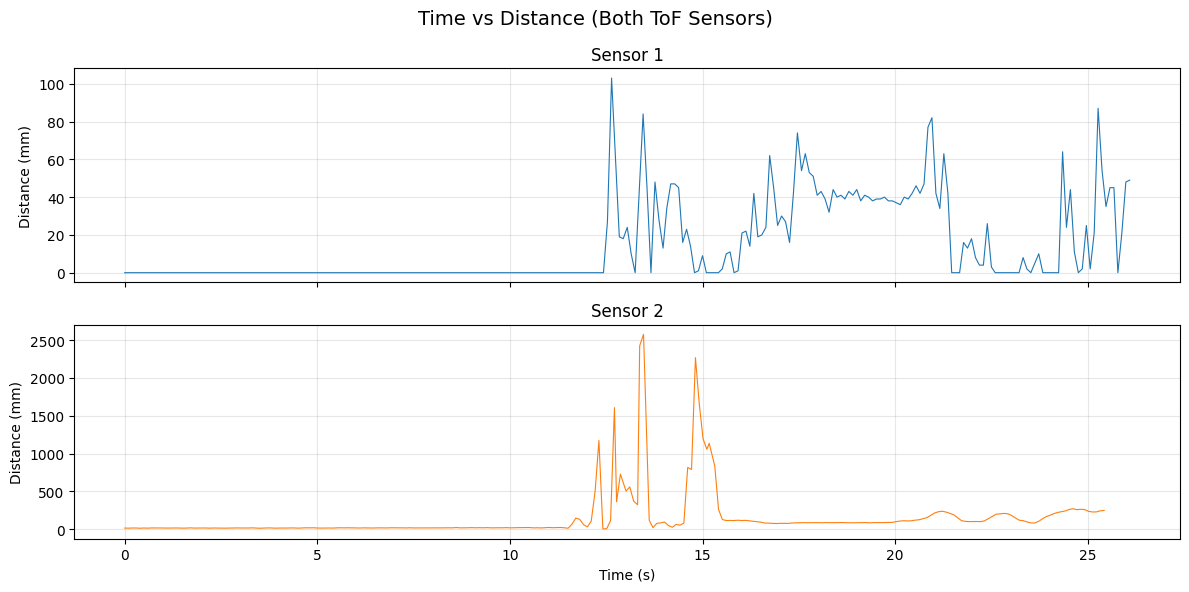

In [29]:
fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
fig.suptitle('Time vs Distance (Both ToF Sensors)', fontsize=14)

if tof1_data['time']:
    t1 = np.array(tof1_data['time']) / 1e6
    t1 = t1 - t1[0]
    axes[0].plot(t1, tof1_data['dist'], linewidth=0.8)
axes[0].set_ylabel('Distance (mm)')
axes[0].set_title('Sensor 1')
axes[0].grid(True, alpha=0.3)

if tof2_data['time']:
    t2 = np.array(tof2_data['time']) / 1e6
    t2 = t2 - t2[0]
    axes[1].plot(t2, tof2_data['dist'], linewidth=0.8, color='tab:orange')
axes[1].set_ylabel('Distance (mm)')
axes[1].set_title('Sensor 2')
axes[1].set_xlabel('Time (s)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../../images/tof_time_vs_distance.png', dpi=150, bbox_inches='tight')
plt.show()


---
## 4. IMU Data (Accelerometer + Gyroscope)
Retrieve the IMU circular buffer and plot accelerometer and gyroscope data.

In [24]:
# Clear and retrieve IMU data
imu_data = {
    'time': [], 'acc_x': [], 'acc_y': [], 'acc_z': [],
    'gyr_x': [], 'gyr_y': [], 'gyr_z': [],
    'mag_x': [], 'mag_y': [], 'mag_z': [],
}
transfer_done = False

ble.send_command(CMD.SEND_IMU_DATA, "")
while not transfer_done:
    await asyncio.sleep(0.1)

print(f"Received {len(imu_data['time'])} IMU samples")


Received 255 IMU samples


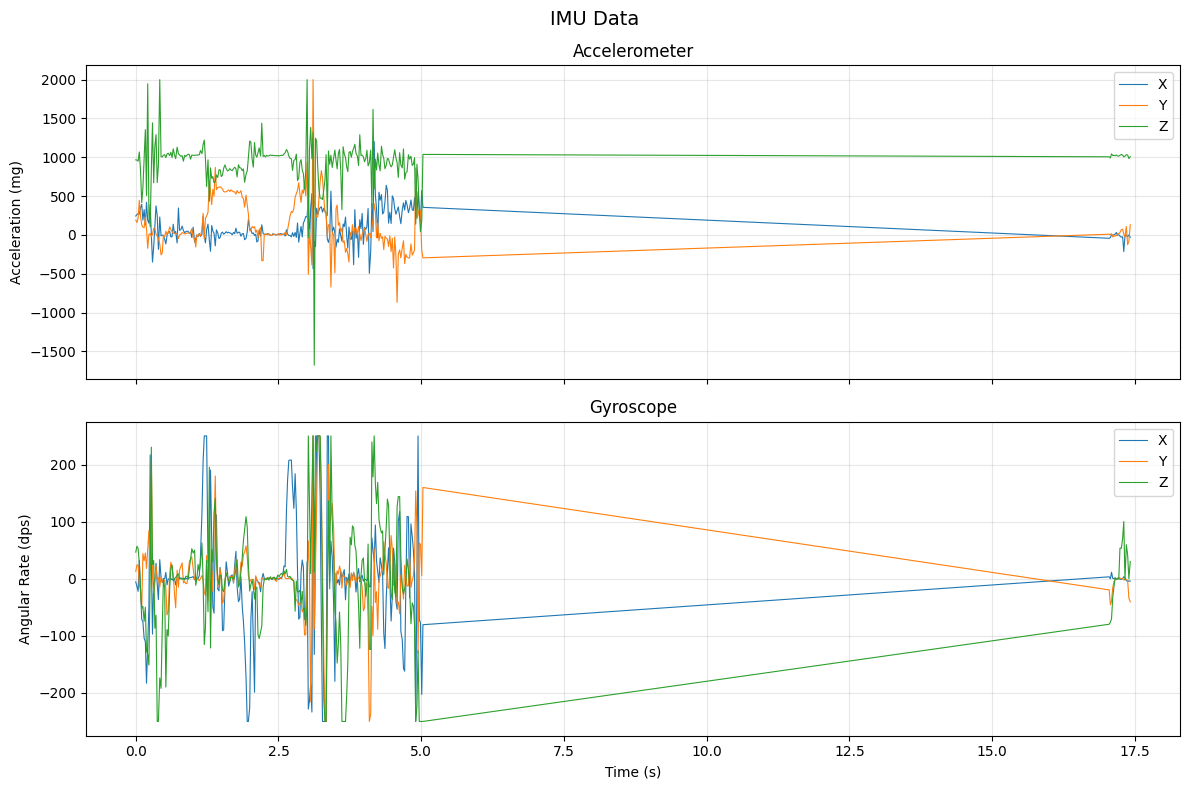

In [25]:
t = np.array(imu_data['time']) / 1e6
t = t - t[0]

fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
fig.suptitle('IMU Data', fontsize=14)

# Accelerometer
for key, label in [('acc_x', 'X'), ('acc_y', 'Y'), ('acc_z', 'Z')]:
    axes[0].plot(t, imu_data[key], linewidth=0.8, label=label)
axes[0].set_ylabel('Acceleration (mg)')
axes[0].set_title('Accelerometer')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Gyroscope
for key, label in [('gyr_x', 'X'), ('gyr_y', 'Y'), ('gyr_z', 'Z')]:
    axes[1].plot(t, imu_data[key], linewidth=0.8, label=label)
axes[1].set_ylabel('Angular Rate (dps)')
axes[1].set_title('Gyroscope')
axes[1].set_xlabel('Time (s)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../../images/imu_data.png', dpi=150, bbox_inches='tight')
plt.show()


---
## 5. Combined ToF + IMU Angle Plot
Plot ToF distance and IMU-derived pitch/roll angle on the same time axis.

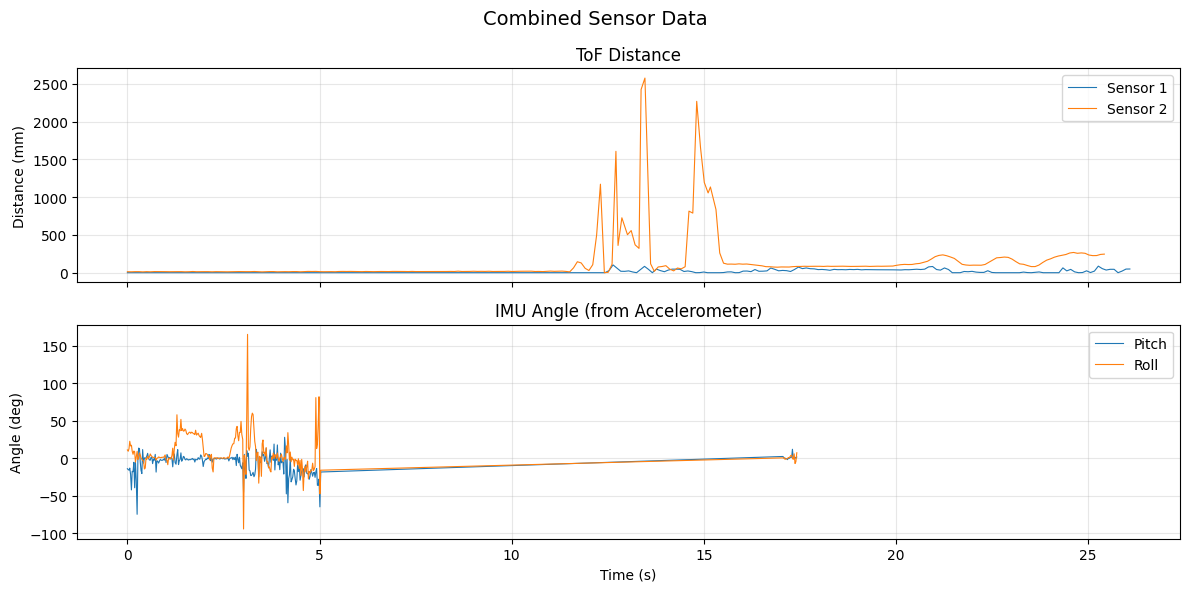

In [26]:
# Compute pitch and roll from accelerometer
acc_x = np.array(imu_data['acc_x'])
acc_y = np.array(imu_data['acc_y'])
acc_z = np.array(imu_data['acc_z'])

pitch = np.degrees(np.arctan2(-acc_x, np.sqrt(acc_y**2 + acc_z**2)))
roll = np.degrees(np.arctan2(acc_y, acc_z))

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
fig.suptitle('Combined Sensor Data', fontsize=14)

# ToF on top
if tof1_data['time']:
    t1 = np.array(tof1_data['time']) / 1e6
    t1 = t1 - t1[0]
    ax1.plot(t1, tof1_data['dist'], linewidth=0.8, label='Sensor 1')
if tof2_data['time']:
    t2 = np.array(tof2_data['time']) / 1e6
    t2 = t2 - t2[0]
    ax1.plot(t2, tof2_data['dist'], linewidth=0.8, label='Sensor 2')
ax1.set_ylabel('Distance (mm)')
ax1.set_title('ToF Distance')
ax1.legend()
ax1.grid(True, alpha=0.3)

# IMU angles on bottom
t_imu = np.array(imu_data['time']) / 1e6
t_imu = t_imu - t_imu[0]
ax2.plot(t_imu, pitch, linewidth=0.8, label='Pitch')
ax2.plot(t_imu, roll, linewidth=0.8, label='Roll')
ax2.set_ylabel('Angle (deg)')
ax2.set_xlabel('Time (s)')
ax2.set_title('IMU Angle (from Accelerometer)')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../../images/tof_imu_combined.png', dpi=150, bbox_inches='tight')
plt.show()


---
## 6. Ranging Speed Analysis
Compute the time between consecutive ToF readings to measure sensor speed and loop frequency.

In [27]:
for data, label in [(tof1_data, 'Sensor 1'), (tof2_data, 'Sensor 2')]:
    if len(data['time']) > 1:
        dts = np.diff(np.array(data['time'])) / 1e3  # microseconds -> milliseconds
        print(f"{label}: mean dt = {np.mean(dts):.1f} ms, std = {np.std(dts):.1f} ms, freq = {1000/np.mean(dts):.1f} Hz")
    else:
        print(f"{label}: not enough data")

if len(imu_data['time']) > 1:
    imu_dts = np.diff(np.array(imu_data['time'])) / 1e3
    print(f"IMU: mean dt = {np.mean(imu_dts):.1f} ms, std = {np.std(imu_dts):.1f} ms, freq = {1000/np.mean(imu_dts):.1f} Hz")


Sensor 1: mean dt = 102.7 ms, std = 2.4 ms, freq = 9.7 Hz
Sensor 2: mean dt = 100.1 ms, std = 7.2 ms, freq = 10.0 Hz
IMU: mean dt = 68.6 ms, std = 751.4 ms, freq = 14.6 Hz


---
## Disconnect

In [28]:
# ble.disconnect()
